In [1]:
%pip install --upgrade pip
%pip install tensorflow
%pip install numpy
%pip install scipy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp311-cp311-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp311-cp311-win_amd64.whl.metadata (3.9 kB)
  Using cached ker

In [2]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, regularizers, callbacks

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


TensorFlow entities such as data shuffling, initialization of model weights, and splitting of data sets often involve some degree of randomness. Without controlling this randomness, each run of your code could lead to slightly different results, which is typically undesirable when comparing models or trying to reproduce results.

In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Deliverable 1: Data Loading and Preprocessing
## 1.1 Load CSV files and convert pixel values into image tensors


In [4]:

# 1.1 Load CSV files
TRAIN_CSV = "sign_mnist_train.csv"
TEST_CSV = "sign_mnist_test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (27455, 785)
Test shape: (7172, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  p

In [5]:
# 4. Separate labels and pixels
X_train_full = train_df.drop("label", axis=1).values.astype("float32")
y_train_raw = train_df["label"].values.astype("int32")

X_test_full = test_df.drop("label", axis=1).values.astype("float32")
y_test_raw = test_df["label"].values.astype("int32")

print("X_train_full shape:", X_train_full.shape)
print("y_train_raw shape:", y_train_raw.shape)
print("X_test_full shape:", X_test_full.shape)
print("y_test_raw shape:", y_test_raw.shape)

X_train_full shape: (27455, 784)
y_train_raw shape: (27455,)
X_test_full shape: (7172, 784)
y_test_raw shape: (7172,)


In [6]:
# 5. Remap labels to 0...23
#    This is important because some versions of Sign Language MNIST
#    may use non-contiguous raw labels.
unique_raw_labels = np.sort(np.unique(y_train_raw))
num_classes = len(unique_raw_labels)

# Create raw label -> contiguous index mapping
raw_to_idx = {raw_label: idx for idx, raw_label in enumerate(unique_raw_labels)}
idx_to_raw = {idx: raw_label for raw_label, idx in raw_to_idx.items()}

# Sign Language MNIST uses 24 classes:
# A, B, C, D, E, F, G, H, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y
letters = list("ABCDEFGHIKLMNOPQRSTUVWXY")

# Create contiguous index -> letter mapping
idx_to_letter = {idx: letters[idx] for idx in range(num_classes)}

# Apply remapping
y_train_full = np.array([raw_to_idx[y] for y in y_train_raw], dtype=np.int32)
y_test = np.array([raw_to_idx[y] for y in y_test_raw], dtype=np.int32)

print("Unique raw labels:", unique_raw_labels)
print("Number of classes:", num_classes)
print("Index to letter mapping:", idx_to_letter)

Unique raw labels: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Number of classes: 24
Index to letter mapping: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}


In [7]:
# 6. Reshape flat pixel rows into image tensors
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
image_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

X_train_full = X_train_full.reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
X_test_full = X_test_full.reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

print("Reshaped training images:", X_train_full.shape)
print("Reshaped test images:", X_test_full.shape)

Reshaped training images: (27455, 28, 28, 1)
Reshaped test images: (7172, 28, 28, 1)


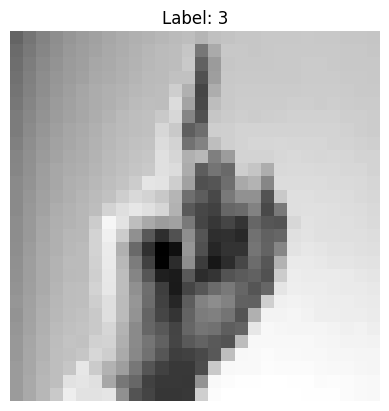

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train_full[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train_full[0]}")
plt.axis("off")
plt.show()

## 1.2 Normalize to 0, 1


In [9]:
# 7. Normalize and optionally whiten
APPLY_WHITENING = True

# Keep a display copy of the test images after only [0,1] scaling
# so sample plots look natural later
X_test_display = X_test_full / 255.0

# Scale all images to [0, 1]
X_train_full = X_train_full / 255.0
X_test_full = X_test_full / 255.0

def per_image_whiten(images):
    """
    Zero-center and standardize each image independently.
    This can help reduce per-image dynamic range differences.
    """
    means = np.mean(images, axis=(1, 2, 3), keepdims=True)
    stds = np.std(images, axis=(1, 2, 3), keepdims=True)
    stds = np.maximum(stds, 1e-6)  # prevent division by zero
    return (images - means) / stds

if APPLY_WHITENING:
    X_train_full = per_image_whiten(X_train_full)
    X_test_full = per_image_whiten(X_test_full)

print("Training data range after preprocessing:")
print("Min:", X_train_full.min(), "Max:", X_train_full.max())

Training data range after preprocessing:
Min: -6.086524 Max: 3.5141728


## 1.3 Create Validation split and Training set

In [10]:
VALIDATION_SPLIT = 0.20

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test_full.shape, y_test.shape)

Training set: (21964, 28, 28, 1) (21964,)
Validation set: (5491, 28, 28, 1) (5491,)
Test set: (7172, 28, 28, 1) (7172,)


In [11]:
# =========================
# 8. Optional class weights
# =========================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0157232704402517), 1: np.float64(1.1326320132013201), 2: np.float64(1.0001821493624772), 3: np.float64(0.956287008011146), 4: np.float64(1.19473455178416), 5: np.float64(0.9503288335064036), 6: np.float64(1.0495030581039755), 7: np.float64(1.129835390946502), 8: np.float64(0.9840501792114695), 9: np.float64(1.0271230826786382), 10: np.float64(0.9216179926149715), 11: np.float64(1.0843206951026856), 12: np.float64(0.9936663047412233), 13: np.float64(0.956287008011146), 14: np.float64(1.0519157088122606), 15: np.float64(0.8945910720104269), 16: np.float64(0.884219001610306), 17: np.float64(0.9542926659714981), 18: np.float64(0.9643484369511767), 19: np.float64(0.9851094366702547), 20: np.float64(1.056774441878368), 21: np.float64(0.933843537414966), 22: np.float64(0.9829931972789115), 23: np.float64(1.023676360924683)}


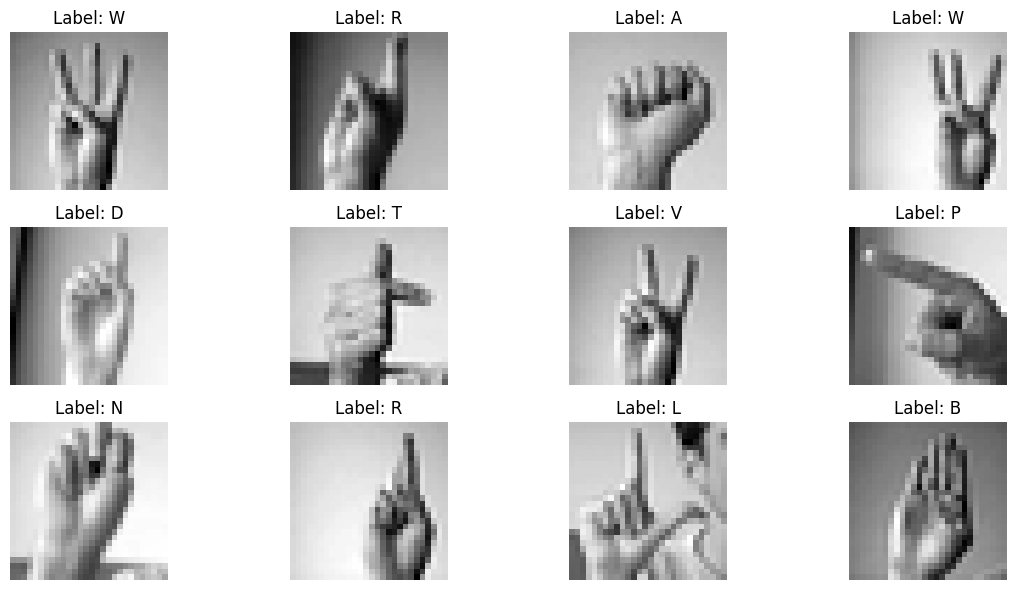

In [12]:
# =========================
# 9. Visualize sample images
# =========================
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    
    img = X_train[i].squeeze()
    
    # If whitening is enabled, rescale for display only
    img_display = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    plt.imshow(img_display, cmap="gray")
    plt.title(f"Label: {idx_to_letter[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# =========================
# 10. Build tf.data datasets
# =========================
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test_full, y_test, training=False)

In [14]:
# 11. Safe data augmentation
# Small rotations, zoom, and translation are usually safe.
# Horizontal flipping is intentionally NOT used because sign gestures
# may be handedness-sensitive.

rotation_factor = 0.03   # about ±10 degrees
zoom_factor = 0.15
translation_factor = 0.10

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=rotation_factor, fill_mode="nearest"),
    layers.RandomZoom(height_factor=zoom_factor, width_factor=zoom_factor, fill_mode="nearest"),
    layers.RandomTranslation(
        height_factor=translation_factor,
        width_factor=translation_factor,
        fill_mode="nearest"
    ),
], name="data_augmentation")

In [15]:
# 12. Helper function for Conv-BN-ReLU blocks
def conv_bn_relu(x, filters, kernel_size, l2_reg, padding="same"):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        padding=padding,
        kernel_regularizer=l2_reg
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

# CNN Architectures
## 2.1 Define a baseline CNN


In [16]:
# =========================
# 13. Model A: Baseline CNN (LeNet-style)
# =========================
def build_model_a(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)
    
    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Model_A_Baseline_LeNet")
    return model

## 2.2 Enhanced CNN architectures


In [17]:
# 14. Model B: AlexNet-inspired deeper CNN
def build_model_b(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)
    
    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)
    
    # Conv 1
    x = conv_bn_relu(x, 64, (5, 5), l2_reg)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)  # overlapping-style pooling
    
    # Conv 2
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    
    # Conv 3
    x = conv_bn_relu(x, 256, (3, 3), l2_reg)
    
    # Conv 4
    x = conv_bn_relu(x, 256, (3, 3), l2_reg)
    
    # Conv 5
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Model_B_AlexNet_Inspired")
    return model

In [18]:
# 15. Model C: Compact VGG-style CNN
def build_model_c(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)
    
    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)
    
    # Block 1
    x = conv_bn_relu(x, 32, (3, 3), l2_reg)
    x = conv_bn_relu(x, 32, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 2
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 3
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Model_C_Compact_VGG")
    return model

## Justify design choices


In [19]:
# 16. Build model dictionary
DROPOUT_RATE = 0.5
WEIGHT_DECAY = 5e-4

model_builders = {
    "Model A - Baseline CNN": lambda: build_model_a(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    ),
    "Model B - AlexNet-inspired CNN": lambda: build_model_b(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    ),
    "Model C - Compact VGG-style CNN": lambda: build_model_c(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    )
}

# Inspect model summaries
for model_name, builder in model_builders.items():
    print("\n" + "=" * 80)
    print(model_name)
    model = builder()
    model.summary()


Model A - Baseline CNN


Model: "Model_A_Baseline_LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,448 (1.62 MB)

 Trainable params: 423,448 (1.62 MB)

...

Model: "Model_C_Compact_VGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 7, 7, 128)      │             

 Total params: 307,832 (1.17 MB)

 Trainable params: 306,936 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
# 17. Compile helper and callbacks
def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def safe_filename(name):
    return "".join(ch if ch.isalnum() else "_" for ch in name)

def get_callbacks(model_name, early_stop_patience, lr_patience, min_lr):
    file_name = f"best_{safe_filename(model_name)}.keras"
    
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.1,
            patience=lr_patience,
            min_lr=min_lr,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            file_name,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

# Deliverable 3: Training, Testing, and Evaluation

## 3.1 Hyperparameter tuning

In [21]:
# 18. Training function
def train_and_evaluate(
    model_name,
    model_builder,
    train_ds,
    val_ds,
    test_ds,
    learning_rate,
    epochs,
    early_stop_patience,
    lr_patience,
    min_lr,
    use_class_weights=False,
    class_weight_dict=None
):
    print("\n" + "=" * 100)
    print(f"Training {model_name}")
    print("=" * 100)
    
    model = model_builder()
    model = compile_model(model, learning_rate=learning_rate)
    
    start_time = time.time()
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(
            model_name=model_name,
            early_stop_patience=early_stop_patience,
            lr_patience=lr_patience,
            min_lr=min_lr
        ),
        class_weight=class_weight_dict if use_class_weights else None,
        verbose=1
    )
    
    end_time = time.time()
    training_time = end_time - start_time
    
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    result = {
        "model": model_name,
        "params": model.count_params(),
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "best_val_loss": min(history.history["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "training_time_sec": training_time
    }
    
    return model, history, result

In [22]:
# =========================
# 19. Train all three models
# =========================
EPOCHS = 30
LEARNING_RATE = 1e-3

# Extra training controls kept here because they belong to training
EARLY_STOP_PATIENCE = 6
LR_PATIENCE = 3
MIN_LR = 1e-6

trained_models = {}
histories = {}
results = []

for model_name, builder in model_builders.items():
    model, history, result = train_and_evaluate(
        model_name=model_name,
        model_builder=builder,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        early_stop_patience=EARLY_STOP_PATIENCE,
        lr_patience=LR_PATIENCE,
        min_lr=MIN_LR,
        use_class_weights=False,
        class_weight_dict=class_weight_dict
    )
    
    trained_models[model_name] = model
    histories[model_name] = history
    results.append(result)


Training Model A - Baseline CNN
Epoch 1/30
340/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3211 - loss: 2.3917
Epoch 1: val_loss improved from None to 0.46669, saving model to best_Model_A___Baseline_CNN.keras

Epoch 1: finished saving model to best_Model_A___Baseline_CNN.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4898 - loss: 1.7695 - val_accuracy: 0.8920 - val_loss: 0.4667 - learning_rate: 0.0010
Epoch 2/30
339/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7340 - loss: 0.9397
Epoch 2: val_loss improved from 0.46669 to 0.30159, saving model to best_Model_A___Baseline_CNN.keras

Epoch 2: finished saving model to best_Model_A___Baseline_CNN.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7630 - loss: 0.8611 - val_accuracy: 0.9645 - val_loss: 0.3016 - learning_rate: 0.0010
Epoch 3/30
338/344 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8263 - loss: 0.6693
Epoch 3: val_loss improved from 0.30159 to 0.22305, saving model to best_Model_A___Basel

KeyboardInterrupt: 